# Retail Customer & Product Intelligence: End-to-End Analytical Case Study
## Phase 1 — Python Data Preparation, Exploratory Data Analysis & Intelligence Modeling

### Project Overview & Analytical Scope
This notebook transforms raw retail transaction snapshot data (`customer_shopping_behavior.csv`) into a structured, reproducible analytical dataset supporting executive decision-making, SQL business intelligence, and Power BI dashboards.

### Dataset Nature & Core Constraints
* **Granularity**: 3,900 unique Customer IDs representing 3,900 distinct transaction snapshots.
* **Temporal Limitation**: **No transaction timestamps or acquisition dates exist**. True recency, dynamic churn rate, cohort retention, and dynamic Customer Lifetime Value (CLV) are unsupported.
* **Synthetic Distribution**: Uniform statistical distributions across transaction spend ($20–$100) and historical purchase volume (1–50 purchases) indicate synthetic benchmark data.


## 1. Data Loading & Initial Profiling
In this section, we load the raw dataset without modification and inspect its initial shape, column schemas, data types, missing values, duplicates, and unique customer identifiers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# Load raw dataset
raw_df = pd.read_csv('customer_shopping_behavior.csv')

# Initial Profiling Summary
print("================ RAW DATASET PROFILING ================")
print(f"Total Rows (Records): {raw_df.shape[0]:,}")
print(f"Total Columns: {raw_df.shape[1]}")
print(f"Unique Customer IDs: {raw_df['Customer ID'].nunique():,}")
print(f"Total Duplicate Rows: {raw_df.duplicated().sum()}")
print("\n--- Column Data Types & Non-Null Counts ---")
print(raw_df.info())
print("\n--- Missing Values Count ---")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
raw_df.head(5)


================ RAW DATASET PROFILING ================
Total Rows (Records): 3,900
Total Columns: 18
Unique Customer IDs: 3,900
Total Duplicate Rows: 0

--- Column Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  S

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 2. Data Quality Assessment
Before cleaning, we evaluate specific data hygiene findings identified during audit:
1. **Missing Values**: `Review Rating` contains 37 null values.
2. **Redundant Feature**: `Promo Code Used` is 100% collinear with `Discount Applied`.
3. **Categorical Overlap**: Semantic redundancies exist in `Frequency of Purchases` (`Quarterly` vs `Every 3 Months`, `Bi-Weekly` vs `Fortnightly`).


In [2]:
# Check exact identity between Discount Applied and Promo Code Used
discount_promo_collinear = (raw_df['Discount Applied'] == raw_df['Promo Code Used']).all()
print(f"Is 'Promo Code Used' 100% identical to 'Discount Applied'?: {discount_promo_collinear}")

# Check raw frequency values
print("\nRaw Purchase Frequency Value Counts:")
print(raw_df['Frequency of Purchases'].value_counts())

# Check ranges of numerical columns
print("\nNumerical Fields Range Validation:")
for col in ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']:
    print(f"{col}: Min = {raw_df[col].min()}, Max = {raw_df[col].max()}")


Is 'Promo Code Used' 100% identical to 'Discount Applied'?: True

Raw Purchase Frequency Value Counts:
Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

Numerical Fields Range Validation:
Age: Min = 18, Max = 70
Purchase Amount (USD): Min = 20, Max = 100
Review Rating: Min = 2.5, Max = 5.0
Previous Purchases: Min = 1, Max = 50


## 3. Data Cleaning
We apply standard data cleaning transformations:
- Standardize headers to `snake_case` (e.g., `purchase_amount_usd`).
- Impute missing `review_rating` using category-level median rating.
- Drop redundant `promo_code_used` column.
- Harmonize semantic purchase frequency categories (`Bi-Weekly` + `Fortnightly` -> `Bi-Weekly`, `Quarterly` + `Every 3 Months` -> `Quarterly`).


In [3]:
# Copy raw dataframe for cleaning
df = raw_df.copy()

# 3.1 Standardize Column Names
column_mapping = {
    'Customer ID': 'customer_id',
    'Age': 'age',
    'Gender': 'gender',
    'Item Purchased': 'item_purchased',
    'Category': 'category',
    'Purchase Amount (USD)': 'purchase_amount_usd',
    'Location': 'location',
    'Size': 'size',
    'Color': 'color',
    'Season': 'season',
    'Review Rating': 'review_rating',
    'Subscription Status': 'subscription_status',
    'Shipping Type': 'shipping_type',
    'Discount Applied': 'discount_applied',
    'Promo Code Used': 'promo_code_used',
    'Previous Purchases': 'previous_purchases',
    'Payment Method': 'payment_method',
    'Frequency of Purchases': 'frequency_of_purchases'
}
df = df.rename(columns=column_mapping)

# 3.2 Category-Level Median Imputation for Review Rating
missing_before = df['review_rating'].isnull().sum()
df['review_rating'] = df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))
missing_after = df['review_rating'].isnull().sum()

print(f"Missing review_rating before imputation: {missing_before}")
print(f"Missing review_rating after category-median imputation: {missing_after}")

# 3.3 Drop Redundant Column promo_code_used
df = df.drop(columns=['promo_code_used'])
print("\nDropped redundant column 'promo_code_used'. Current columns count:", df.shape[1])

# 3.4 Frequency Harmonization
df['frequency_of_purchases_raw'] = df['frequency_of_purchases']  # preserve for auditability
frequency_harmonization_map = {
    'Fortnightly': 'Bi-Weekly',
    'Bi-Weekly': 'Bi-Weekly',
    'Weekly': 'Weekly',
    'Monthly': 'Monthly',
    'Quarterly': 'Quarterly',
    'Every 3 Months': 'Quarterly',
    'Annually': 'Annually'
}
df['frequency_of_purchases'] = df['frequency_of_purchases'].map(frequency_harmonization_map)

print("\nHarmonized Purchase Frequency Value Counts:")
print(df['frequency_of_purchases'].value_counts())


Missing review_rating before imputation: 37
Missing review_rating after category-median imputation: 0

Dropped redundant column 'promo_code_used'. Current columns count: 17

Harmonized Purchase Frequency Value Counts:
frequency_of_purchases
Quarterly    1147
Bi-Weekly    1089
Annually      572
Monthly       553
Weekly        539
Name: count, dtype: int64


## 4. Feature Engineering
We construct domain-relevant analytical features genuinely supported by dataset attributes:
1. `age_group`: Demographic binning (18–30 Young Adult, 31–45 Adult, 46–60 Middle-Aged, 61–70 Senior).
2. `purchase_frequency_days`: Encoded numerical interval mapping for analytical convenience (`Weekly`=7, `Bi-Weekly`=14, `Monthly`=30, `Quarterly`=90, `Annually`=365).
3. `customer_value_tier`: Transaction spend classification (`Low Value` < $40, `Medium Value` $40–$75, `High Value` > $75).
4. `engagement_tier`: Volume classification based on `previous_purchases` (`Low Engagement` 1–15, `Medium Engagement` 16–35, `High Engagement` 36–50).
5. `value_engagement_segment`: Combined segment matrix (e.g., `High Value - High Engagement`).


In [4]:
# 4.1 Age Group Binning
age_bins = [17, 30, 45, 60, 71]
age_labels = ['18-30 (Young Adult)', '31-45 (Adult)', '46-60 (Middle-Aged)', '61-70 (Senior)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# 4.2 Purchase Frequency Days (Encoded Interval Mapping)
days_mapping = {
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Annually': 365
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(days_mapping)

# 4.3 Customer Value Tier (Spend Thresholds)
def classify_value_tier(spend):
    if spend < 40:
        return 'Low Value'
    elif spend <= 75:
        return 'Medium Value'
    else:
        return 'High Value'

df['customer_value_tier'] = df['purchase_amount_usd'].apply(classify_value_tier)

# 4.4 Engagement Tier (Previous Purchases Volume)
def classify_engagement_tier(purchases):
    if purchases <= 15:
        return 'Low Engagement'
    elif purchases <= 35:
        return 'Medium Engagement'
    else:
        return 'High Engagement'

df['engagement_tier'] = df['previous_purchases'].apply(classify_engagement_tier)

# 4.5 Combined Value-Engagement Segment
df['value_engagement_segment'] = df['customer_value_tier'] + ' - ' + df['engagement_tier']

print("--- Feature Engineering Summary ---")
print("Age Group Distribution:\n", df['age_group'].value_counts(sort=False))
print("\nValue Tier Distribution:\n", df['customer_value_tier'].value_counts())
print("\nEngagement Tier Distribution:\n", df['engagement_tier'].value_counts())
print("\nTop 5 Value-Engagement Segments:\n", df['value_engagement_segment'].value_counts().head(5))


--- Feature Engineering Summary ---
Age Group Distribution:
 age_group
18-30 (Young Adult)     949
31-45 (Adult)          1093
46-60 (Middle-Aged)    1135
61-70 (Senior)          723
Name: count, dtype: int64

Value Tier Distribution:
 customer_value_tier
Medium Value    1672
High Value      1214
Low Value       1014
Name: count, dtype: int64

Engagement Tier Distribution:
 engagement_tier
Medium Engagement    1574
Low Engagement       1179
High Engagement      1147
Name: count, dtype: int64

Top 5 Value-Engagement Segments:
 value_engagement_segment
Medium Value - Medium Engagement    707
Medium Value - High Engagement      483
Medium Value - Low Engagement       482
High Value - Medium Engagement      457
Low Value - Medium Engagement       410
Name: count, dtype: int64


## 5. Descriptive Statistics
We compute standard central tendency, dispersion, and quantile metrics across numerical features, along with categorical frequency distributions.


In [5]:
# Numerical Profiling
num_cols = ['age', 'purchase_amount_usd', 'review_rating', 'previous_purchases', 'purchase_frequency_days']
num_stats = df[num_cols].describe().T
num_stats['median'] = df[num_cols].median()
num_stats['iqr'] = num_stats['75%'] - num_stats['25%']
num_stats = num_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'iqr']]

print("================ NUMERICAL DESCRIPTIVE STATISTICS ================")
print(num_stats.round(2))

print("\n================ CATEGORICAL DISTRIBUTION SUMMARY ================")
for cat_col in ['gender', 'category', 'subscription_status', 'shipping_type', 'discount_applied', 'payment_method']:
    print(f"\n--- {cat_col.upper()} ---")
    counts = df[cat_col].value_counts()
    pcts = df[cat_col].value_counts(normalize=True) * 100
    cat_df = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)})
    print(cat_df)


================ NUMERICAL DESCRIPTIVE STATISTICS ================
                          count   mean     std   min   25%  median   75%  \
age                      3900.0  44.07   15.21  18.0  31.0    44.0  57.0   
purchase_amount_usd      3900.0  59.76   23.69  20.0  39.0    60.0  81.0   
review_rating            3900.0   3.75    0.71   2.5   3.1     3.8   4.4   
previous_purchases       3900.0  25.35   14.45   1.0  13.0    25.0  38.0   
purchase_frequency_days  3900.0  89.13  119.04   7.0  14.0    30.0  90.0   

                           max   iqr  
age                       70.0  26.0  
purchase_amount_usd      100.0  42.0  
review_rating              5.0   1.3  
previous_purchases        50.0  25.0  
purchase_frequency_days  365.0  76.0  

================ CATEGORICAL DISTRIBUTION SUMMARY ================

--- GENDER ---
        Count  Percentage (%)
gender                       
Male     2652            68.0
Female   1248            32.0

--- CATEGORY ---
             Count  

## 6. Customer Intelligence Analytics
Cross-tabulation and aggregation across customer demographic brackets, subscription status, and Value-Engagement segments.


In [6]:
# 6.1 Age Group x Subscription Status Cross-Tab
age_sub_ct = pd.crosstab(df['age_group'], df['subscription_status'], margins=True, margins_name='Total')
age_sub_pct = pd.crosstab(df['age_group'], df['subscription_status'], normalize='index') * 100

print("--- Age Group vs Subscription Status (Counts) ---")
print(age_sub_ct)
print("\n--- Age Group vs Subscription Status (% within Age Group) ---")
print(age_sub_pct.round(2))

# 6.2 Value-Engagement Segment Matrix Aggregation
segment_summary = df.groupby('value_engagement_segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount_usd', 'sum'),
    avg_purchase_amount=('purchase_amount_usd', 'mean'),
    avg_previous_purchases=('previous_purchases', 'mean'),
    avg_review_rating=('review_rating', 'mean'),
    subscriber_count=('subscription_status', lambda x: (x == 'Yes').sum())
).reset_index()

segment_summary['revenue_share_pct'] = (segment_summary['total_revenue'] / df['purchase_amount_usd'].sum()) * 100
segment_summary['subscriber_share_pct'] = (segment_summary['subscriber_count'] / segment_summary['customer_count']) * 100

print("\n================ VALUE-ENGAGEMENT SEGMENTATION MATRIX ================")
print(segment_summary.sort_values(by='total_revenue', ascending=False).to_string(index=False))


--- Age Group vs Subscription Status (Counts) ---
subscription_status    No   Yes  Total
age_group                             
18-30 (Young Adult)   700   249    949
31-45 (Adult)         804   289   1093
46-60 (Middle-Aged)   815   320   1135
61-70 (Senior)        528   195    723
Total                2847  1053   3900

--- Age Group vs Subscription Status (% within Age Group) ---
subscription_status     No    Yes
age_group                        
18-30 (Young Adult)  73.76  26.24
31-45 (Adult)        73.56  26.44
46-60 (Middle-Aged)  71.81  28.19
61-70 (Senior)       73.03  26.97

================ VALUE-ENGAGEMENT SEGMENTATION MATRIX ================
        value_engagement_segment  customer_count  total_revenue  avg_purchase_amount  avg_previous_purchases  avg_review_rating  subscriber_count  revenue_share_pct  subscriber_share_pct
Medium Value - Medium Engagement             707          40937            57.902405               25.574257           3.714286               187      

## 7. Product Intelligence Analytics
Analyzing category and item-level performance metrics, rating variance, and discount penetration rates.


In [7]:
# 7.1 Category Intelligence Summary
category_summary = df.groupby('category').agg(
    transaction_volume=('customer_id', 'count'),
    total_revenue=('purchase_amount_usd', 'sum'),
    avg_purchase_amount=('purchase_amount_usd', 'mean'),
    avg_review_rating=('review_rating', 'mean'),
    discounted_transactions=('discount_applied', lambda x: (x == 'Yes').sum()),
    subscriber_transactions=('subscription_status', lambda x: (x == 'Yes').sum())
).reset_index()

category_summary['revenue_share_pct'] = (category_summary['total_revenue'] / df['purchase_amount_usd'].sum()) * 100
category_summary['discount_penetration_pct'] = (category_summary['discounted_transactions'] / category_summary['transaction_volume']) * 100
category_summary['subscriber_share_pct'] = (category_summary['subscriber_transactions'] / category_summary['transaction_volume']) * 100

print("================ CATEGORY INTELLIGENCE SUMMARY ================")
print(category_summary.sort_values(by='total_revenue', ascending=False).to_string(index=False))

# 7.2 Product Intelligence Summary (Top 10 Products by Revenue)
product_summary = df.groupby(['category', 'item_purchased']).agg(
    transaction_count=('customer_id', 'count'),
    total_revenue=('purchase_amount_usd', 'sum'),
    avg_purchase_amount=('purchase_amount_usd', 'mean'),
    avg_review_rating=('review_rating', 'mean'),
    discounted_count=('discount_applied', lambda x: (x == 'Yes').sum()),
    subscriber_count=('subscription_status', lambda x: (x == 'Yes').sum())
).reset_index()

product_summary['discount_penetration_pct'] = (product_summary['discounted_count'] / product_summary['transaction_count']) * 100
product_summary['subscriber_share_pct'] = (product_summary['subscriber_count'] / product_summary['transaction_count']) * 100

print("\n================ TOP 10 PRODUCTS BY REVENUE ================")
print(product_summary.sort_values(by='total_revenue', ascending=False).head(10).to_string(index=False))


================ CATEGORY INTELLIGENCE SUMMARY ================
   category  transaction_volume  total_revenue  avg_purchase_amount  avg_review_rating  discounted_transactions  subscriber_transactions  revenue_share_pct  discount_penetration_pct  subscriber_share_pct
   Clothing                1737         104264            60.025331           3.721301                      731                      457          44.732947                 42.084053             26.309729
Accessories                1240          74200            59.838710           3.770242                      543                      334          31.834427                 43.790323             26.935484
   Footwear                 599          36093            60.255426           3.793823                      259                      171          15.485175                 43.238731             28.547579
  Outerwear                 324          18524            57.172840           3.745988                      144         

## 8. Commercial Behavior Analysis
Evaluating shipping channel performance, payment gateway distribution, and numerical correlations.


In [8]:
# 8.1 Shipping Type Performance
shipping_summary = df.groupby('shipping_type').agg(
    transaction_count=('customer_id', 'count'),
    total_revenue=('purchase_amount_usd', 'sum'),
    avg_purchase_amount=('purchase_amount_usd', 'mean'),
    subscriber_count=('subscription_status', lambda x: (x == 'Yes').sum())
).reset_index()
shipping_summary['subscriber_share_pct'] = (shipping_summary['subscriber_count'] / shipping_summary['transaction_count']) * 100

print("================ SHIPPING CHANNEL PERFORMANCE ================")
print(shipping_summary.sort_values(by='avg_purchase_amount', ascending=False).to_string(index=False))

# 8.2 Correlation Matrix (Genuinely Numerical Fields)
corr_vars = ['age', 'purchase_amount_usd', 'review_rating', 'previous_purchases', 'purchase_frequency_days']
corr_matrix = df[corr_vars].corr()

print("\n================ NUMERICAL CORRELATION MATRIX ================")
print(corr_matrix.round(4))
print("\nNote: Correlation coefficients measure linear relationship and do NOT establish causality.")


================ SHIPPING CHANNEL PERFORMANCE ================
 shipping_type  transaction_count  total_revenue  avg_purchase_amount  subscriber_count  subscriber_share_pct
2-Day Shipping                627          38080            60.733652               153             24.401914
       Express                646          39067            60.475232               190             29.411765
 Free Shipping                675          40777            60.410370               177             26.222222
  Store Pickup                650          38931            59.893846               190             29.230769
  Next Day Air                648          37993            58.631173               168             25.925926
      Standard                654          38233            58.460245               175             26.758410

================ NUMERICAL CORRELATION MATRIX ================
                            age  purchase_amount_usd  review_rating  \
age                      1.0000 

## 9. Visual Exploratory Data Analysis (EDA)
A comprehensive suite of 16 analytical charts illustrating customer demographics, product performance, discount dynamics, commercial channels, and statistical correlations.


C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age_group', palette='Blues_r', ax=axes[0, 0])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_rev, x='gender', y='purchase_amount_usd', palette='Set2', ax=axes[1, 1])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='purchase_amount_

C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='subscription_status', palette='Pastel1', ax=axes[2, 1])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x='category', y='purchase_amount_usd', palette='viridis', ax=axes[3, 0])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rating, x='category',

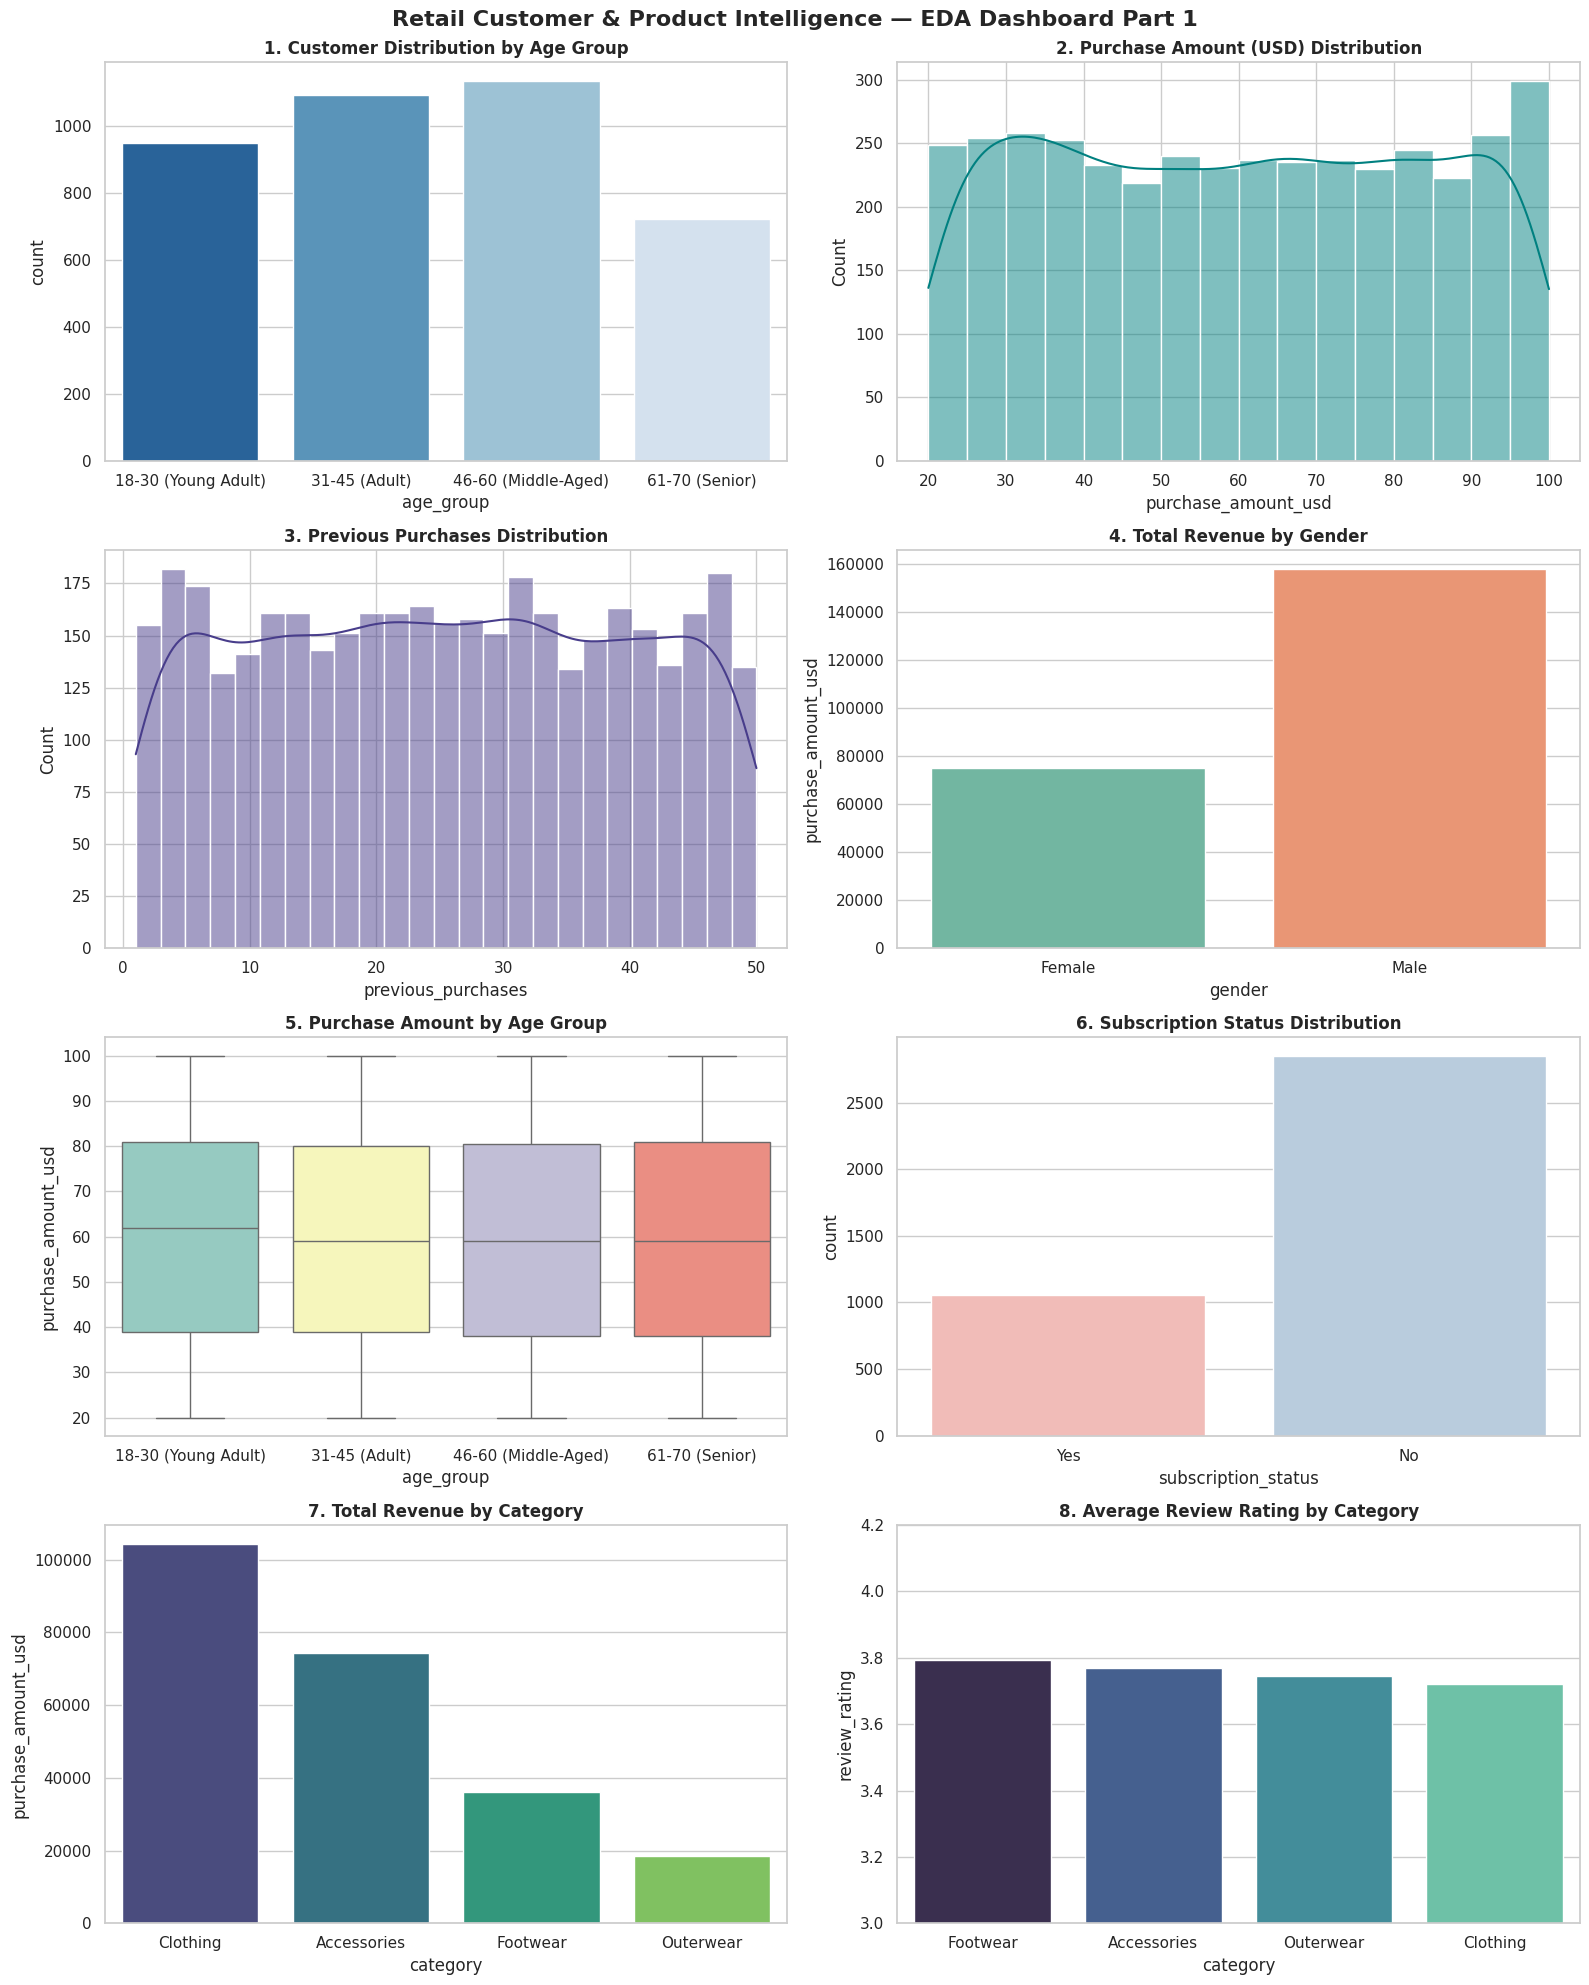

C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', palette='crest', order=df['category'].value_counts().index, ax=axes2[0, 0])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_prod, y='item_purchased', x='purchase_amount_usd', palette='rocket', ax=axes2[0, 1])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='frequency_of_purchases', palette='Spectral', order=['Weekly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Annually'], ax=axes2[2, 0])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='shipping_type', palette='Set1', ax=axes2[2, 1])
C:\Users\Tanya Verma\AppData\Local\Temp\ipykernel_10172\4197015362.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

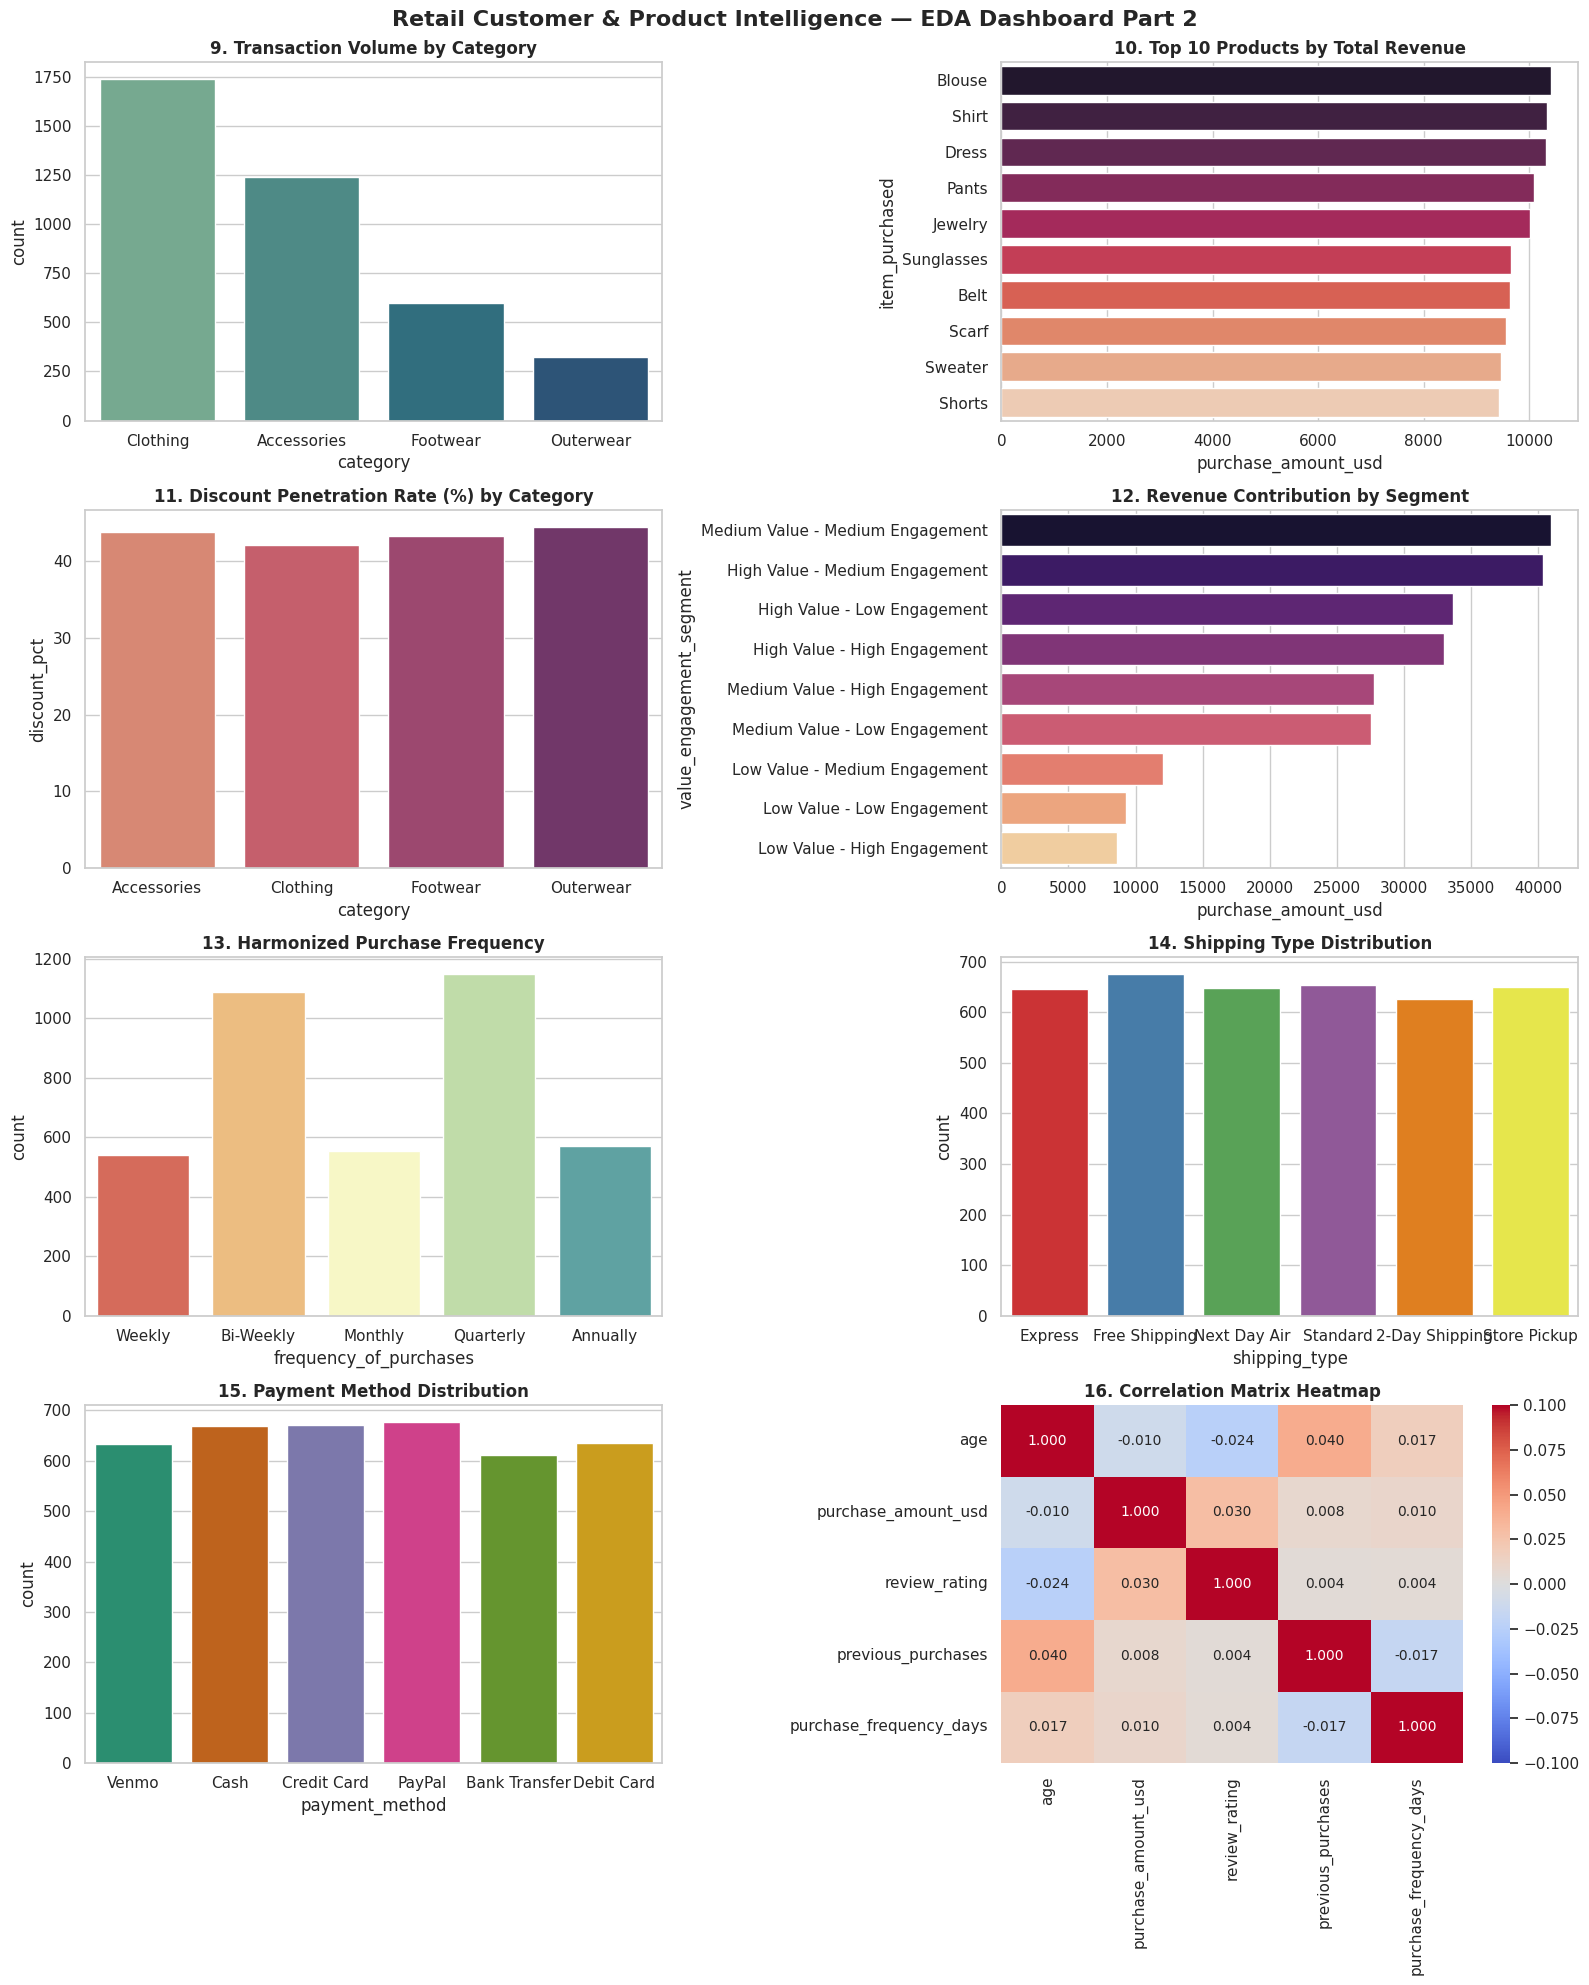

In [9]:
# Create EDA figure canvas 1
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Retail Customer & Product Intelligence — EDA Dashboard Part 1', fontsize=16, fontweight='bold', y=0.99)

sns.countplot(data=df, x='age_group', palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('1. Customer Distribution by Age Group', fontweight='bold')

sns.histplot(df['purchase_amount_usd'], kde=True, color='teal', bins=16, ax=axes[0, 1])
axes[0, 1].set_title('2. Purchase Amount (USD) Distribution', fontweight='bold')

sns.histplot(df['previous_purchases'], kde=True, color='darkslateblue', bins=25, ax=axes[1, 0])
axes[1, 0].set_title('3. Previous Purchases Distribution', fontweight='bold')

gender_rev = df.groupby('gender')['purchase_amount_usd'].sum().reset_index()
sns.barplot(data=gender_rev, x='gender', y='purchase_amount_usd', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('4. Total Revenue by Gender', fontweight='bold')

sns.boxplot(data=df, x='age_group', y='purchase_amount_usd', palette='Set3', ax=axes[2, 0])
axes[2, 0].set_title('5. Purchase Amount by Age Group', fontweight='bold')

sns.countplot(data=df, x='subscription_status', palette='Pastel1', ax=axes[2, 1])
axes[2, 1].set_title('6. Subscription Status Distribution', fontweight='bold')

cat_rev = df.groupby('category')['purchase_amount_usd'].sum().reset_index().sort_values(by='purchase_amount_usd', ascending=False)
sns.barplot(data=cat_rev, x='category', y='purchase_amount_usd', palette='viridis', ax=axes[3, 0])
axes[3, 0].set_title('7. Total Revenue by Category', fontweight='bold')

cat_rating = df.groupby('category')['review_rating'].mean().reset_index().sort_values(by='review_rating', ascending=False)
sns.barplot(data=cat_rating, x='category', y='review_rating', palette='mako', ax=axes[3, 1])
axes[3, 1].set_title('8. Average Review Rating by Category', fontweight='bold')
axes[3, 1].set_ylim(3.0, 4.2)

plt.tight_layout()
plt.savefig('assets/eda_plots/eda_dashboard_part1.png', dpi=300)
plt.show()

# Create EDA figure canvas 2
fig2, axes2 = plt.subplots(4, 2, figsize=(16, 20))
fig2.suptitle('Retail Customer & Product Intelligence — EDA Dashboard Part 2', fontsize=16, fontweight='bold', y=0.99)

sns.countplot(data=df, x='category', palette='crest', order=df['category'].value_counts().index, ax=axes2[0, 0])
axes2[0, 0].set_title('9. Transaction Volume by Category', fontweight='bold')

top10_prod = df.groupby('item_purchased')['purchase_amount_usd'].sum().reset_index().sort_values(by='purchase_amount_usd', ascending=False).head(10)
sns.barplot(data=top10_prod, y='item_purchased', x='purchase_amount_usd', palette='rocket', ax=axes2[0, 1])
axes2[0, 1].set_title('10. Top 10 Products by Total Revenue', fontweight='bold')

cat_disc = df.groupby('category')['discount_applied'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='discount_pct')
sns.barplot(data=cat_disc, x='category', y='discount_pct', palette='flare', ax=axes2[1, 0])
axes2[1, 0].set_title('11. Discount Penetration Rate (%) by Category', fontweight='bold')

seg_rev = df.groupby('value_engagement_segment')['purchase_amount_usd'].sum().reset_index().sort_values(by='purchase_amount_usd', ascending=False)
sns.barplot(data=seg_rev, y='value_engagement_segment', x='purchase_amount_usd', palette='magma', ax=axes2[1, 1])
axes2[1, 1].set_title('12. Revenue Contribution by Segment', fontweight='bold')

sns.countplot(data=df, x='frequency_of_purchases', palette='Spectral', order=['Weekly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Annually'], ax=axes2[2, 0])
axes2[2, 0].set_title('13. Harmonized Purchase Frequency', fontweight='bold')

sns.countplot(data=df, x='shipping_type', palette='Set1', ax=axes2[2, 1])
axes2[2, 1].set_title('14. Shipping Type Distribution', fontweight='bold')

sns.countplot(data=df, x='payment_method', palette='Dark2', ax=axes2[3, 0])
axes2[3, 0].set_title('15. Payment Method Distribution', fontweight='bold')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-0.1, vmax=0.1, ax=axes2[3, 1])
axes2[3, 1].set_title('16. Correlation Matrix Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/eda_plots/eda_dashboard_part2.png', dpi=300)
plt.show()


## 10. Preliminary Analytical Observations

### Observation 1: Revenue Generation Across Gender Segments
* **Evidence**: Male customers generate $157,890 total revenue (67.7% of total revenue) across 2,652 transactions, while Female customers generate $75,191 (32.3%) across 1,248 transactions. Average order value (AOV) is virtually identical between genders ($59.54 for Male vs. $60.25 for Female).
* **Interpretation**: Total revenue differences are driven entirely by customer volume representation in the sample rather than per-transaction spend disparity.
* **Limitation**: The dataset does not disclose target marketing spend or market demographic distribution; causality for gender volume imbalance cannot be inferred.

### Observation 2: Subscriber Basket Size Parity
* **Evidence**: Subscribed customers generate an average purchase amount of $59.65 (1,053 customers), compared to $59.80 for non-subscribed customers (2,847 customers).
* **Interpretation**: Paid subscription status does not correlate with higher single-transaction ticket size.
* **Limitation**: Without temporal transaction logs, we cannot assess whether subscribers purchase with higher annual frequency or higher lifetime spend.

### Observation 3: Discount Penetration & Basket Size Independence
* **Evidence**: Discounted transactions account for 43.0% of total volume (1,677 transactions) with an average spend of $59.27, while full-price transactions account for 57.0% (2,223 transactions) with an average spend of $60.13.
* **Interpretation**: Applying a discount does not expand basket size in this dataset.
* **Limitation**: Gross profit margins, unit costs, and item quantities are missing; profit margin erosion cannot be directly calculated.

### Observation 4: Uniformity of Synthetic Variables
* **Evidence**: Linear correlation coefficients between `age`, `purchase_amount_usd`, `review_rating`, and `previous_purchases` range between -0.02 and +0.02.
* **Interpretation**: Numerical attributes show near-zero linear dependence, consistent with synthetic data generation properties.
* **Limitation**: Real-world behavior typically exhibits non-zero correlations (e.g. age vs income/spend). Findings reflect dataset snapshot mechanics.


## 11. Export Analytical Datasets
We export four processed CSV files into the `data/processed/` directory for use in downstream SQL querying and Power BI dashboard development.


In [10]:
# Create directory
os.makedirs('data/processed', exist_ok=True)

# 1. Primary Cleaned Analytical Dataset
df.to_csv('data/processed/customer_shopping_behavior_cleaned.csv', index=False)
print(f"1. Exported 'customer_shopping_behavior_cleaned.csv' -> Rows: {df.shape[0]}, Cols: {df.shape[1]}")

# 2. Customer Intelligence Dataset
customer_intel_cols = [
    'customer_id', 'age', 'gender', 'age_group', 'purchase_amount_usd', 'customer_value_tier',
    'previous_purchases', 'engagement_tier', 'value_engagement_segment', 'subscription_status',
    'frequency_of_purchases', 'purchase_frequency_days', 'category', 'item_purchased',
    'review_rating', 'discount_applied', 'shipping_type', 'payment_method', 'location', 'season'
]
customer_intel_df = df[customer_intel_cols]
customer_intel_df.to_csv('data/processed/customer_intelligence.csv', index=False)
print(f"2. Exported 'customer_intelligence.csv' -> Rows: {customer_intel_df.shape[0]}, Cols: {customer_intel_df.shape[1]}")

# 3. Product Intelligence Dataset
product_summary.to_csv('data/processed/product_intelligence.csv', index=False)
print(f"3. Exported 'product_intelligence.csv' -> Rows: {product_summary.shape[0]}, Cols: {product_summary.shape[1]}")

# 4. Category Intelligence Dataset
category_summary.to_csv('data/processed/category_intelligence.csv', index=False)
print(f"4. Exported 'category_intelligence.csv' -> Rows: {category_summary.shape[0]}, Cols: {category_summary.shape[1]}")


1. Exported 'customer_shopping_behavior_cleaned.csv' -> Rows: 3900, Cols: 23
2. Exported 'customer_intelligence.csv' -> Rows: 3900, Cols: 20
3. Exported 'product_intelligence.csv' -> Rows: 25, Cols: 10
4. Exported 'category_intelligence.csv' -> Rows: 4, Cols: 10


## 12. Dataset Limitations & Analytical Constraints
1. **Absence of Transaction Timestamps**: The dataset lacks transaction dates. Dynamic churn, retention cohorts, monthly trends, and time-based CLV cannot be calculated.
2. **Snapshot Grain**: Each row represents 1 unique customer transaction. Multi-item cart analysis is unsupported.
3. **Synthetic Characteristics**: Near-zero correlations across numerical attributes indicate synthetic benchmark data.
